# Clase 4 · Modelos predictivos para la toma de decisiones
## Caso práctico en Colab: probabilidad de compra y valor esperado

### Objetivo de la práctica
En esta sesión construiremos un caso de uso con **dos problemas predictivos complementarios**:

1. **Clasificación:** estimar qué clientes tienen mayor probabilidad de comprar en una campaña.
2. **Regresión:** estimar cuánto podría comprar un cliente si responde a la campaña.

### Idea central
Un modelo predictivo no toma la decisión por nosotros. El modelo ayuda a **ordenar la incertidumbre** para decidir mejor.

> La mejor decisión comercial no siempre consiste en contactar al cliente con mayor probabilidad de compra; también debemos considerar el valor económico esperado.

## Caso de uso: campaña inteligente
Una empresa retail multicanal quiere lanzar una nueva campaña comercial. Hasta ahora contactaba a toda la base de clientes, con alto coste y resultados variables. La gerencia quiere priorizar:

- clientes con mayor probabilidad de compra,
- clientes con mayor potencial de valor,
- y clientes con mayor **valor esperado** para la campaña.

La práctica usará un dataset limpio, ya formateado y con **100.000 registros**, para enfocarnos en el análisis y en los algoritmos, no en preprocesamiento pesado.

## Variables del dataset
El dataset contiene variables históricas y comportamentales:

- `edad_cliente`
- `antiguedad_meses`
- `frecuencia_compra`
- `ticket_promedio`
- `dias_desde_ultima_compra`
- `canal_preferido`
- `tipo_cliente`
- `region`
- `uso_descuento`
- `visitas_web_30d`
- `compras_ult_90d`
- `reclamos_ult_12m`

Y dos variables objetivo:

- `compro_campania`: variable binaria para clasificación.
- `valor_compra_futura`: variable numérica para regresión.

In [1]:
# Librerías base
import pandas as pd
import numpy as np

# Visualización y evaluación
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# División de datos y transformación de variables
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

# Modelos de clasificación
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

# Modelos de regresión
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 140)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

# Paso 1 · Cargar y comprender el dataset

En este primer paso verificamos que el dataset esté correctamente cargado y que las variables disponibles sean consistentes con el problema predictivo.

In [2]:
#from google.colab import files
#uploaded = files.upload()

In [3]:
df = pd.read_csv('dataset_clase4_modelos_predictivos_100k.csv')
print('Dimensiones del dataset:', df.shape)
df.head()

Dimensiones del dataset: (100000, 16)


,cliente_id,edad_cliente,antiguedad_meses,frecuencia_compra,ticket_promedio,dias_desde_ultima_compra,canal_preferido,tipo_cliente,region,uso_descuento,visitas_web_30d,compras_ult_90d,reclamos_ult_12m,compro_campania,valor_compra_futura,valor_real_campania
0,1,33,1,3,90.1900,191,Online,Recurrente,Sur,0.1810,7,1,0,1,145.8700,145.8700
1,2,23,2,4,59.0500,42,Online,Recurrente,Centro,0.3780,4,1,0,1,115.4200,115.4200
2,3,41,15,8,106.1300,29,Online,Recurrente,Centro,0.3370,12,3,0,1,252.9000,252.9000
3,4,38,8,5,78.8500,48,Mixto,Nuevo,Oriente,0.2700,7,1,0,1,174.9000,174.9000
4,5,54,1,6,83.9000,10,Tienda,Nuevo,Centro,0.3360,6,3,0,1,182.1600,182.1600


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 16 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   cliente_id                100000 non-null  int64  
 1   edad_cliente              100000 non-null  int64  
 2   antiguedad_meses          100000 non-null  int64  
 3   frecuencia_compra         100000 non-null  int64  
 4   ticket_promedio           100000 non-null  float64
 5   dias_desde_ultima_compra  100000 non-null  int64  
 6   canal_preferido           100000 non-null  str    
 7   tipo_cliente              100000 non-null  str    
 8   region                    100000 non-null  str    
 9   uso_descuento             100000 non-null  float64
 10  visitas_web_30d           100000 non-null  int64  
 11  compras_ult_90d           100000 non-null  int64  
 12  reclamos_ult_12m          100000 non-null  int64  
 13  compro_campania           100000 non-null  int64  
 14  

In [5]:
# Verificamos que no existan valores faltantes.
df.isnull().sum()

cliente_id                  0
edad_cliente                0
antiguedad_meses            0
frecuencia_compra           0
ticket_promedio             0
dias_desde_ultima_compra    0
canal_preferido             0
tipo_cliente                0
region                      0
uso_descuento               0
visitas_web_30d             0
compras_ult_90d             0
reclamos_ult_12m            0
compro_campania             0
valor_compra_futura         0
valor_real_campania         0
dtype: int64

## Lectura inicial
Este dataset ya está limpio y listo para modelar. A diferencia de la Clase 2, no vamos a profundizar en ETL. A diferencia de la Clase 3, no nos quedaremos sólo en indicadores descriptivos.

Aquí queremos usar la información disponible para **anticipar comportamiento futuro**.

# Paso 2 · Formular los dos problemas predictivos

## Problema 1: clasificación
Pregunta: **¿comprará el cliente en la campaña?**

Variable objetivo:

```python
compro_campania
```

## Problema 2: regresión
Pregunta: **¿cuál podría ser el valor de compra futura del cliente?**

Variable objetivo:

```python
valor_compra_futura
```

> Nota metodológica: la regresión logística no es técnicamente un modelo de regresión para una variable continua; se utiliza para clasificación. Por eso, para estimar valor numérico usaremos regresión lineal, árbol regresor y máquina de soporte vectorial para regresión.

In [6]:
# Definimos variables explicativas
features = [
    'edad_cliente', 'antiguedad_meses', 'frecuencia_compra', 'ticket_promedio',
    'dias_desde_ultima_compra', 'canal_preferido', 'tipo_cliente', 'region',
    'uso_descuento', 'visitas_web_30d', 'compras_ult_90d', 'reclamos_ult_12m'
]

X = df[features].copy()
y_clf = df['compro_campania'].copy()
y_reg = df['valor_compra_futura'].copy()

categoricas = ['canal_preferido', 'tipo_cliente', 'region']
numericas = [c for c in features if c not in categoricas]

print('Variables numéricas:', numericas)
print('Variables categóricas:', categoricas)

Variables numéricas: ['edad_cliente', 'antiguedad_meses', 'frecuencia_compra', 'ticket_promedio', 'dias_desde_ultima_compra', 'uso_descuento', 'visitas_web_30d', 'compras_ult_90d', 'reclamos_ult_12m']
Variables categóricas: ['canal_preferido', 'tipo_cliente', 'region']


# Paso 3 · Preparar transformación de variables

Los algoritmos necesitan variables numéricas. Por eso:

- las variables numéricas se escalan,
- las variables categóricas se transforman con One-Hot Encoding.

Esto permite que los modelos trabajen con todos los campos del dataset.

In [7]:
preprocesador = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numericas),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categoricas)
    ]
)

# Paso 4 · Modelos de clasificación

## Objetivo
Evaluar al menos tres algoritmos para estimar la probabilidad o clase de compra:

1. Árbol de decisión (`DecisionTreeClassifier`)
2. Random Forest (`RandomForestClassifier`)
3. Red neuronal multicapa (`MLPClassifier`)

> En un dataset tabular como este, una GNN estricta requeriría una estructura de grafo explícita. Para fines pedagógicos de clasificación tabular usaremos una red neuronal multicapa, que es más adecuada para este tipo de ejercicio.

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_clf, test_size=0.30, random_state=42, stratify=y_clf
)

modelos_clasificacion = {
    'Árbol de decisión': DecisionTreeClassifier(max_depth=7, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=120, max_depth=10, random_state=42, n_jobs=-1),
    'Red neuronal MLP': MLPClassifier(hidden_layer_sizes=(32, 16), max_iter=60, random_state=42)
}

resultados_clf = []
modelos_clf_entrenados = {}

for nombre, modelo in modelos_clasificacion.items():
    pipe = Pipeline(steps=[
        ('preprocesador', preprocesador),
        ('modelo', modelo)
    ])

    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)

    resultados_clf.append({
        'modelo': nombre,
        'accuracy': acc,
        'precision': prec,
        'recall': rec
    })
    modelos_clf_entrenados[nombre] = pipe

resultados_clf = pd.DataFrame(resultados_clf).sort_values('accuracy', ascending=False)
resultados_clf

c:\dev\edu\diplomado\Diplomado en Big Data, Analytics y Business Intelligence V1\04_Visualizacion_de_Datos_y_Data_Recovery\entregas\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (60) reached and the optimization hasn't converged yet.
  warnings.warn(


,modelo,accuracy,precision,recall
1,Random Forest,0.6312,0.6205,0.6329
2,Red neuronal MLP,0.6294,0.6133,0.6556
0,Árbol de decisión,0.6128,0.5995,0.6275


## Matrices de confusión
La matriz de confusión ayuda a entender en qué se equivoca cada modelo:

- Verdaderos positivos: clientes que el modelo predijo como compradores y efectivamente compraron.
- Falsos positivos: clientes que el modelo priorizaría, pero no compraron.
- Falsos negativos: clientes que el modelo no priorizaría, pero sí compraron.
- Verdaderos negativos: clientes correctamente identificados como no compradores.

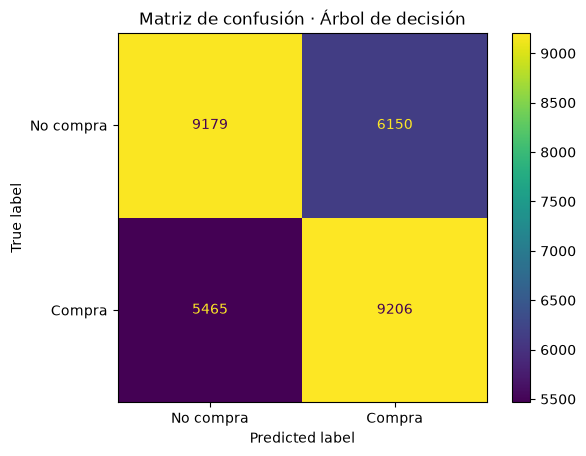

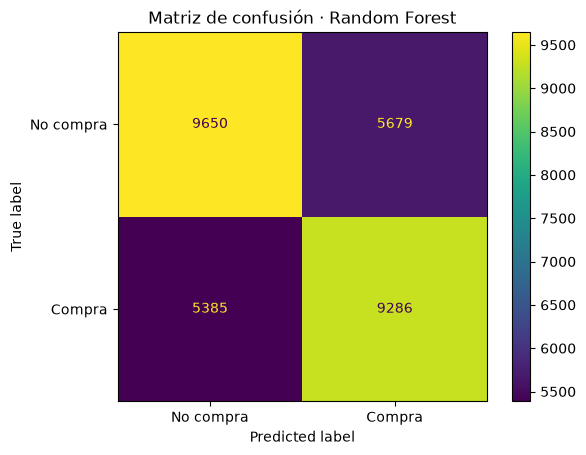

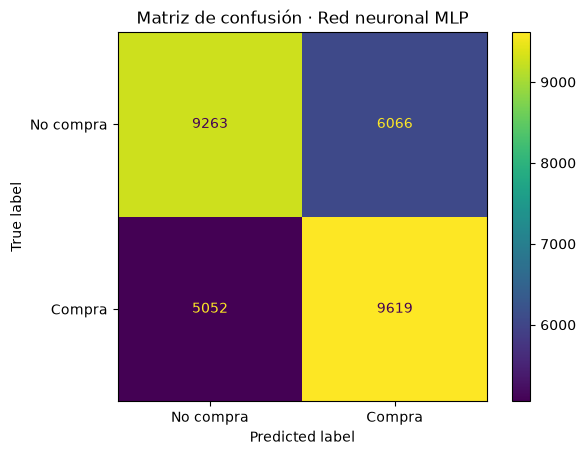

In [9]:
for nombre, modelo in modelos_clf_entrenados.items():
    y_pred = modelo.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No compra', 'Compra'])
    disp.plot(values_format='d')
    plt.title(f'Matriz de confusión · {nombre}')
    plt.show()

# Paso 5 · Modelos de regresión

## Objetivo
Ahora estimaremos el valor de compra futura. Probamos tres algoritmos:

1. Árbol regresor (`DecisionTreeRegressor`)
2. Regresión lineal (`LinearRegression`)
3. Máquina de soporte vectorial para regresión (`SVR`)

### Métrica principal
Usaremos **RMSE** porque expresa el error en las mismas unidades monetarias del valor que estamos prediciendo.

In [10]:
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X, y_reg, test_size=0.30, random_state=42
)

# Para SVR usamos una muestra de entrenamiento por eficiencia didáctica.
# El dataset completo tiene 100.000 registros, pero SVR puede ser más costoso computacionalmente.
svr_train_sample = 15000
X_train_r_svr = X_train_r.sample(n=svr_train_sample, random_state=42)
y_train_r_svr = y_train_r.loc[X_train_r_svr.index]

modelos_regresion = {
    'Árbol regresor': DecisionTreeRegressor(max_depth=8, random_state=42),
    'Regresión lineal': LinearRegression(),
    'SVR': SVR(kernel='rbf', C=10, epsilon=5)
}

resultados_reg = []
modelos_reg_entrenados = {}

for nombre, modelo in modelos_regresion.items():
    pipe = Pipeline(steps=[
        ('preprocesador', preprocesador),
        ('modelo', modelo)
    ])

    if nombre == 'SVR':
        pipe.fit(X_train_r_svr, y_train_r_svr)
    else:
        pipe.fit(X_train_r, y_train_r)

    y_pred_r = pipe.predict(X_test_r)
    rmse = np.sqrt(mean_squared_error(y_test_r, y_pred_r))
    mae = mean_absolute_error(y_test_r, y_pred_r)
    r2 = r2_score(y_test_r, y_pred_r)

    resultados_reg.append({
        'modelo': nombre,
        'RMSE': rmse,
        'MAE': mae,
        'R2': r2
    })
    modelos_reg_entrenados[nombre] = pipe

resultados_reg = pd.DataFrame(resultados_reg).sort_values('RMSE')
resultados_reg

,modelo,RMSE,MAE,R2
1,Regresión lineal,27.9210,22.2721,0.6674
2,SVR,28.8520,22.9048,0.6449
0,Árbol regresor,30.2859,24.1303,0.6087


# Paso 6 · Selección del mejor algoritmo

Para clasificación podemos escoger el mejor modelo según `accuracy`, aunque en contextos comerciales también puede ser importante priorizar `recall` o `precision` según el coste del error.

Para regresión escogeremos el modelo con menor `RMSE`.

In [11]:
mejor_clf_nombre = resultados_clf.iloc[0]['modelo']
mejor_reg_nombre = resultados_reg.iloc[0]['modelo']

mejor_clf = modelos_clf_entrenados[mejor_clf_nombre]
mejor_reg = modelos_reg_entrenados[mejor_reg_nombre]

print('Mejor modelo de clasificación:', mejor_clf_nombre)
print('Mejor modelo de regresión:', mejor_reg_nombre)

Mejor modelo de clasificación: Random Forest
Mejor modelo de regresión: Regresión lineal


# Paso 7 · Priorización comercial integrada

Ahora combinamos ambos modelos:

- modelo de clasificación → probabilidad de compra,
- modelo de regresión → valor estimado de compra futura,
- decisión integrada → valor esperado.

Fórmula:

```python
valor_esperado = probabilidad_compra * valor_predicho
```

Esto permite priorizar clientes por impacto comercial esperado, no sólo por probabilidad.

In [12]:
base_scoring = df.copy()

# Probabilidad de compra para todos los clientes
if hasattr(mejor_clf.named_steps['modelo'], 'predict_proba'):
    base_scoring['probabilidad_compra'] = mejor_clf.predict_proba(base_scoring[features])[:, 1]
else:
    base_scoring['probabilidad_compra'] = mejor_clf.predict(base_scoring[features])

# Valor predicho
base_scoring['valor_predicho'] = mejor_reg.predict(base_scoring[features])

# Valor esperado
base_scoring['valor_esperado'] = base_scoring['probabilidad_compra'] * base_scoring['valor_predicho']

base_scoring[['cliente_id', 'probabilidad_compra', 'valor_predicho', 'valor_esperado']].head()

,cliente_id,probabilidad_compra,valor_predicho,valor_esperado
0,1,0.2650,162.2906,43.0039
1,2,0.5176,146.3101,75.7346
2,3,0.7675,234.0709,179.6580
3,4,0.4609,155.8459,71.8357
4,5,0.5332,175.5276,93.6000


In [13]:
# Top 10 clientes priorizados por valor esperado
columnas_priorizacion = [
    'cliente_id', 'canal_preferido', 'tipo_cliente', 'region',
    'frecuencia_compra', 'ticket_promedio', 'dias_desde_ultima_compra',
    'probabilidad_compra', 'valor_predicho', 'valor_esperado'
]

top_10 = base_scoring.sort_values('valor_esperado', ascending=False)[columnas_priorizacion].head(10)
top_10

,cliente_id,canal_preferido,tipo_cliente,region,frecuencia_compra,ticket_promedio,dias_desde_ultima_compra,probabilidad_compra,valor_predicho,valor_esperado
45040,45041,Tienda,Recurrente,Centro,6,370.4600,24,0.7921,420.5417,333.1097
71910,71911,Mixto,Recurrente,Centro,8,279.8900,23,0.8078,400.3559,323.4043
40022,40023,Online,Mayorista,Centro,7,255.6500,47,0.8256,376.2946,310.6602
17683,17684,Tienda,Recurrente,Oriente,9,296.9300,13,0.7884,388.7790,306.5202
78113,78114,Online,Recurrente,Oriente,8,262.5800,26,0.8425,362.5596,305.4424
63193,63194,Online,Recurrente,Norte,8,308.8800,21,0.7869,378.2929,297.6821
84884,84885,Tienda,Mayorista,Oriente,6,420.0000,30,0.6528,455.3511,297.2510
83616,83617,Mixto,Mayorista,Centro,7,258.0800,13,0.7638,383.0993,292.6089
61197,61198,Online,Recurrente,Sur,10,241.1300,61,0.8022,362.2913,290.6180
32284,32285,Online,Mayorista,Oriente,7,222.5000,8,0.7994,359.4693,287.3762


## Interpretación de negocio
Un cliente con alta probabilidad de compra no siempre es el más rentable. La priorización mejora cuando combinamos probabilidad e impacto económico estimado.

> La decisión comercial más sólida combina probabilidad, valor esperado y criterio de negocio.

# Paso 8 · Ejemplo de corrida con un cliente hipotético

Ahora simularemos un cliente nuevo o un cliente candidato a campaña, con valores definidos manualmente. Usaremos los mejores modelos seleccionados para estimar:

1. probabilidad de compra,
2. valor potencial estimado,
3. valor esperado.

In [14]:
cliente_ejemplo = pd.DataFrame([{
    'edad_cliente': 36,
    'antiguedad_meses': 28,
    'frecuencia_compra': 7,
    'ticket_promedio': 135.0,
    'dias_desde_ultima_compra': 18,
    'canal_preferido': 'Online',
    'tipo_cliente': 'Recurrente',
    'region': 'Centro',
    'uso_descuento': 0.25,
    'visitas_web_30d': 12,
    'compras_ult_90d': 3,
    'reclamos_ult_12m': 0
}])

prob_ejemplo = mejor_clf.predict_proba(cliente_ejemplo)[0, 1]
valor_ejemplo = mejor_reg.predict(cliente_ejemplo)[0]
valor_esperado_ejemplo = prob_ejemplo * valor_ejemplo

print(f'Probabilidad estimada de compra: {prob_ejemplo:.2%}')
print(f'Valor estimado de compra futura: {valor_ejemplo:,.2f}')
print(f'Valor esperado de campaña: {valor_esperado_ejemplo:,.2f}')

Probabilidad estimada de compra: 78.56%
Valor estimado de compra futura: 248.01
Valor esperado de campaña: 194.82


# Cierre de la práctica

## Qué aprendimos
- La clasificación permite estimar **quién tiene mayor probabilidad de comprar**.
- La regresión permite estimar **cuánto valor podría generar**.
- La matriz de confusión ayuda a comprender errores de clasificación.
- El RMSE ayuda a estimar el error promedio de predicción numérica.
- La toma de decisiones mejora al combinar probabilidad e impacto esperado.

## Mensaje final
> La predicción no elimina el riesgo; lo vuelve más gestionable.

# Tarea sugerida
1. Cambiar los valores del `cliente_ejemplo`con otros 3 que se consideren y observar cómo cambian la probabilidad y el valor esperado.
2. Comparar si el modelo con mayor accuracy también es el mejor para una decisión comercial.
3. Proponer una regla de campaña para seleccionar clientes: por ejemplo, top 10 %, probabilidad mayor a 70 %, o valor esperado mayor a cierto umbral.
4. Redactar una advertencia metodológica antes de presentar el modelo a gerencia.
5. Establecer la Estrategia/s que debe serguir el Negocio

# **1. Cambiar los valores del cliente_ejemplo con otros 3 que se consideren y observar cómo cambian la probabilidad y el valor esperado.**

In [15]:
cliente_ejemplo_1 = pd.DataFrame([{
    'edad_cliente': 42,
    'antiguedad_meses': 60,
    'frecuencia_compra': 12,
    'ticket_promedio': 250.0,
    'dias_desde_ultima_compra': 5,
    'canal_preferido': 'Online',
    'tipo_cliente': 'Recurrente',
    'region': 'Centro',
    'uso_descuento': 0.10,
    'visitas_web_30d': 18,
    'compras_ult_90d': 6,
    'reclamos_ult_12m': 0
}])

prob_ejemplo = mejor_clf.predict_proba(cliente_ejemplo_1)[0, 1]
valor_ejemplo = mejor_reg.predict(cliente_ejemplo_1)[0]
valor_esperado_ejemplo = prob_ejemplo * valor_ejemplo

print(f'Probabilidad estimada de compra: {prob_ejemplo:.2%}')
print(f'Valor estimado de compra futura: {valor_ejemplo:,.2f}')
print(f'Valor esperado de campaña: {valor_esperado_ejemplo:,.2f}')

Probabilidad estimada de compra: 88.14%
Valor estimado de compra futura: 405.08
Valor esperado de campaña: 357.06


El primer cliente compra frecuentemente, tiene un ticket promedio elevado, compro resientemente, ademas no tiene ningun reclamo.

El modelo estima que este cliente tiene un 88.14% de probabilidad de compra, se espera que el valor de su compra futura fuera de 405.08, siendo el valor esperado 357.06. Al ser datos positivos seria recomendable que este cliente deberia ser priorizado para la campaña.

In [16]:
cliente_ejemplo_2 = pd.DataFrame([{
    'edad_cliente': 31,
    'antiguedad_meses': 18,
    'frecuencia_compra': 4,
    'ticket_promedio': 120.0,
    'dias_desde_ultima_compra': 40,
    'canal_preferido': 'Tienda',
    'tipo_cliente': 'Nuevo',
    'region': 'Norte',
    'uso_descuento': 0.45,
    'visitas_web_30d': 8,
    'compras_ult_90d': 2,
    'reclamos_ult_12m': 1
}])


prob_ejemplo = mejor_clf.predict_proba(cliente_ejemplo_2)[0, 1]
valor_ejemplo = mejor_reg.predict(cliente_ejemplo_2)[0]
valor_esperado_ejemplo = prob_ejemplo * valor_ejemplo

print(f'Probabilidad estimada de compra: {prob_ejemplo:.2%}')
print(f'Valor estimado de compra futura: {valor_ejemplo:,.2f}')
print(f'Valor esperado de campaña: {valor_esperado_ejemplo:,.2f}')

Probabilidad estimada de compra: 46.27%
Valor estimado de compra futura: 175.59
Valor esperado de campaña: 81.25


El segundo cliente ha realizado algunas compras, visita la web, es un cliente nuevo, su gasto promedio es moderadoy tiene un reclamo.

El modelo estima que este cliente tiene un 46.27% de probabilidad de compra, se espera que el valor de su compra futura fuera de 175.59, siendo el valor esperado 81.25. Este es un cliente con un comportamiento intermedio siendo un cliente aceptable, pero tendria menos prioridad a clientes como el cliente 1.

In [17]:
cliente_ejemplo_3 = pd.DataFrame([{
    'edad_cliente': 54,
    'antiguedad_meses': 8,
    'frecuencia_compra': 1,
    'ticket_promedio': 45.0,
    'dias_desde_ultima_compra': 180,
    'canal_preferido': 'Tienda',
    'tipo_cliente': 'Nuevo',
    'region': 'Sur',
    'uso_descuento': 0.80,
    'visitas_web_30d': 2,
    'compras_ult_90d': 0,
    'reclamos_ult_12m': 3
}])

prob_ejemplo = mejor_clf.predict_proba(cliente_ejemplo_3)[0, 1]
valor_ejemplo = mejor_reg.predict(cliente_ejemplo_3)[0]
valor_esperado_ejemplo = prob_ejemplo * valor_ejemplo

print(f'Probabilidad estimada de compra: {prob_ejemplo:.2%}')
print(f'Valor estimado de compra futura: {valor_ejemplo:,.2f}')
print(f'Valor esperado de campaña: {valor_esperado_ejemplo:,.2f}')

Probabilidad estimada de compra: 15.48%
Valor estimado de compra futura: 71.54
Valor esperado de campaña: 11.08


El tercer cliente tiene pocas compras, un ticket promedio bajo, muchos dias sin comprar, visita la web pocas veces y tiene varios reclamos.

El modelo estima que este cliente tiene un 15.48% de probabilidad de compra, se espera que el valor de su compra futura fuera de 71.54, siendo el valor esperado 11.08. Siendo bajas las probabilidades de compra y valor esperado muy reducido, por esta razon no seria recomendable contactar a este cliente.

# **2. Comparar si el modelo con mayor accuracy también es el mejor para una decisión comercial.**


Segun el resultado anteriormente obtenido en el paso 4, se observa que el modelo con mayor Accuracy es el Random Forest, siendo el mejor para la cladificacion. Sin embargo, tener un mayor Accuracy no garantiza que sea la mejor para la toma de decisiones comerciales.

El modelo podria clasificar correctamente la mayoria de los cliente, pero aun asi podria no tomar en cuenta a clientes que talvez generen grandes ingresos. Por esta razon para tomar decisiones comerciales se recomienda utilizar otras metricas como Precision y Recall, que de igual manera se observa en el paso 4.

# **3. Proponer una regla de campaña para seleccionar clientes: por ejemplo, top 10 %, probabilidad mayor a 70 %, o valor esperado mayor a cierto umbral.**


* Los clientes con una probabilidad mayor a 60, poner prioridad ademas de contactarlos para la campaña.
* Entre los anteriores clientes priorizar a los que tengan un valor esperado mayor a 180.
* Si se tuviera un presupuesto limitado, seria seleccionar solo un 15% de los clientes priorizados o segun el presupuesto, seleccionar un porcentaje de los clientes.

# **4. Redactar una advertencia metodológica antes de presentar el modelo a gerencia.**


Se recomendaria que antes de utilizar los resultados del modelo para la toma de decisiones comerciales, seria importante considerar lo siguiente.

El modelo utiliza informacion historica que se nos dio por esta razon el resultado depende de la calidad y la actualizacion de los datos brindados durante el entrenamiento. Si existiera algun cambio o factores externos, esto podria afectar la presicion del modelo. Ademas, de que los resultados obtenidos representan estimacion y no garantiza que un cliente compre. La prediccion debe utilizarse como una herramienta de apoyo y complementarse con la opinio del equipo comercial u otro personal.

# **5. Establecer la Estrategia/s que debe serguir el Negocio**

* Priorizar a los clientes que tienen una mayor valor esperado
* Diseñar campañas segun el tipo de cliente, aunque este no sea un cliente priorizado.
* Actualizar los modelos cada cierto tiempo para que se encuentren actualizados
* Cada vez que se actualiice el codelo identificar oportunidades de mejor y de acuerdo al resultado ajustar las estrategias comercieles.

<div style="
  background: linear-gradient(135deg, #1a1a2e 0%, #0f0f1a 100%);
  padding: 20px 28px 20px 28px;
  border-radius: 20px;
  font-family: 'Segoe UI', system-ui, -apple-system, sans-serif;
  box-shadow: 0 8px 24px rgba(0,0,0,0.5);
  border: 1px solid #818285;
  max-width: 66%;
">
  <div style="display: flex; align-items: center; gap: 14px; margin-bottom: 16px;">
    <svg xmlns="http://www.w3.org/2000/svg" xmlns:xlink="http://www.w3.org/1999/xlink" width="100" height="100" viewBox="0 0 100 100">
        <image xlink:href="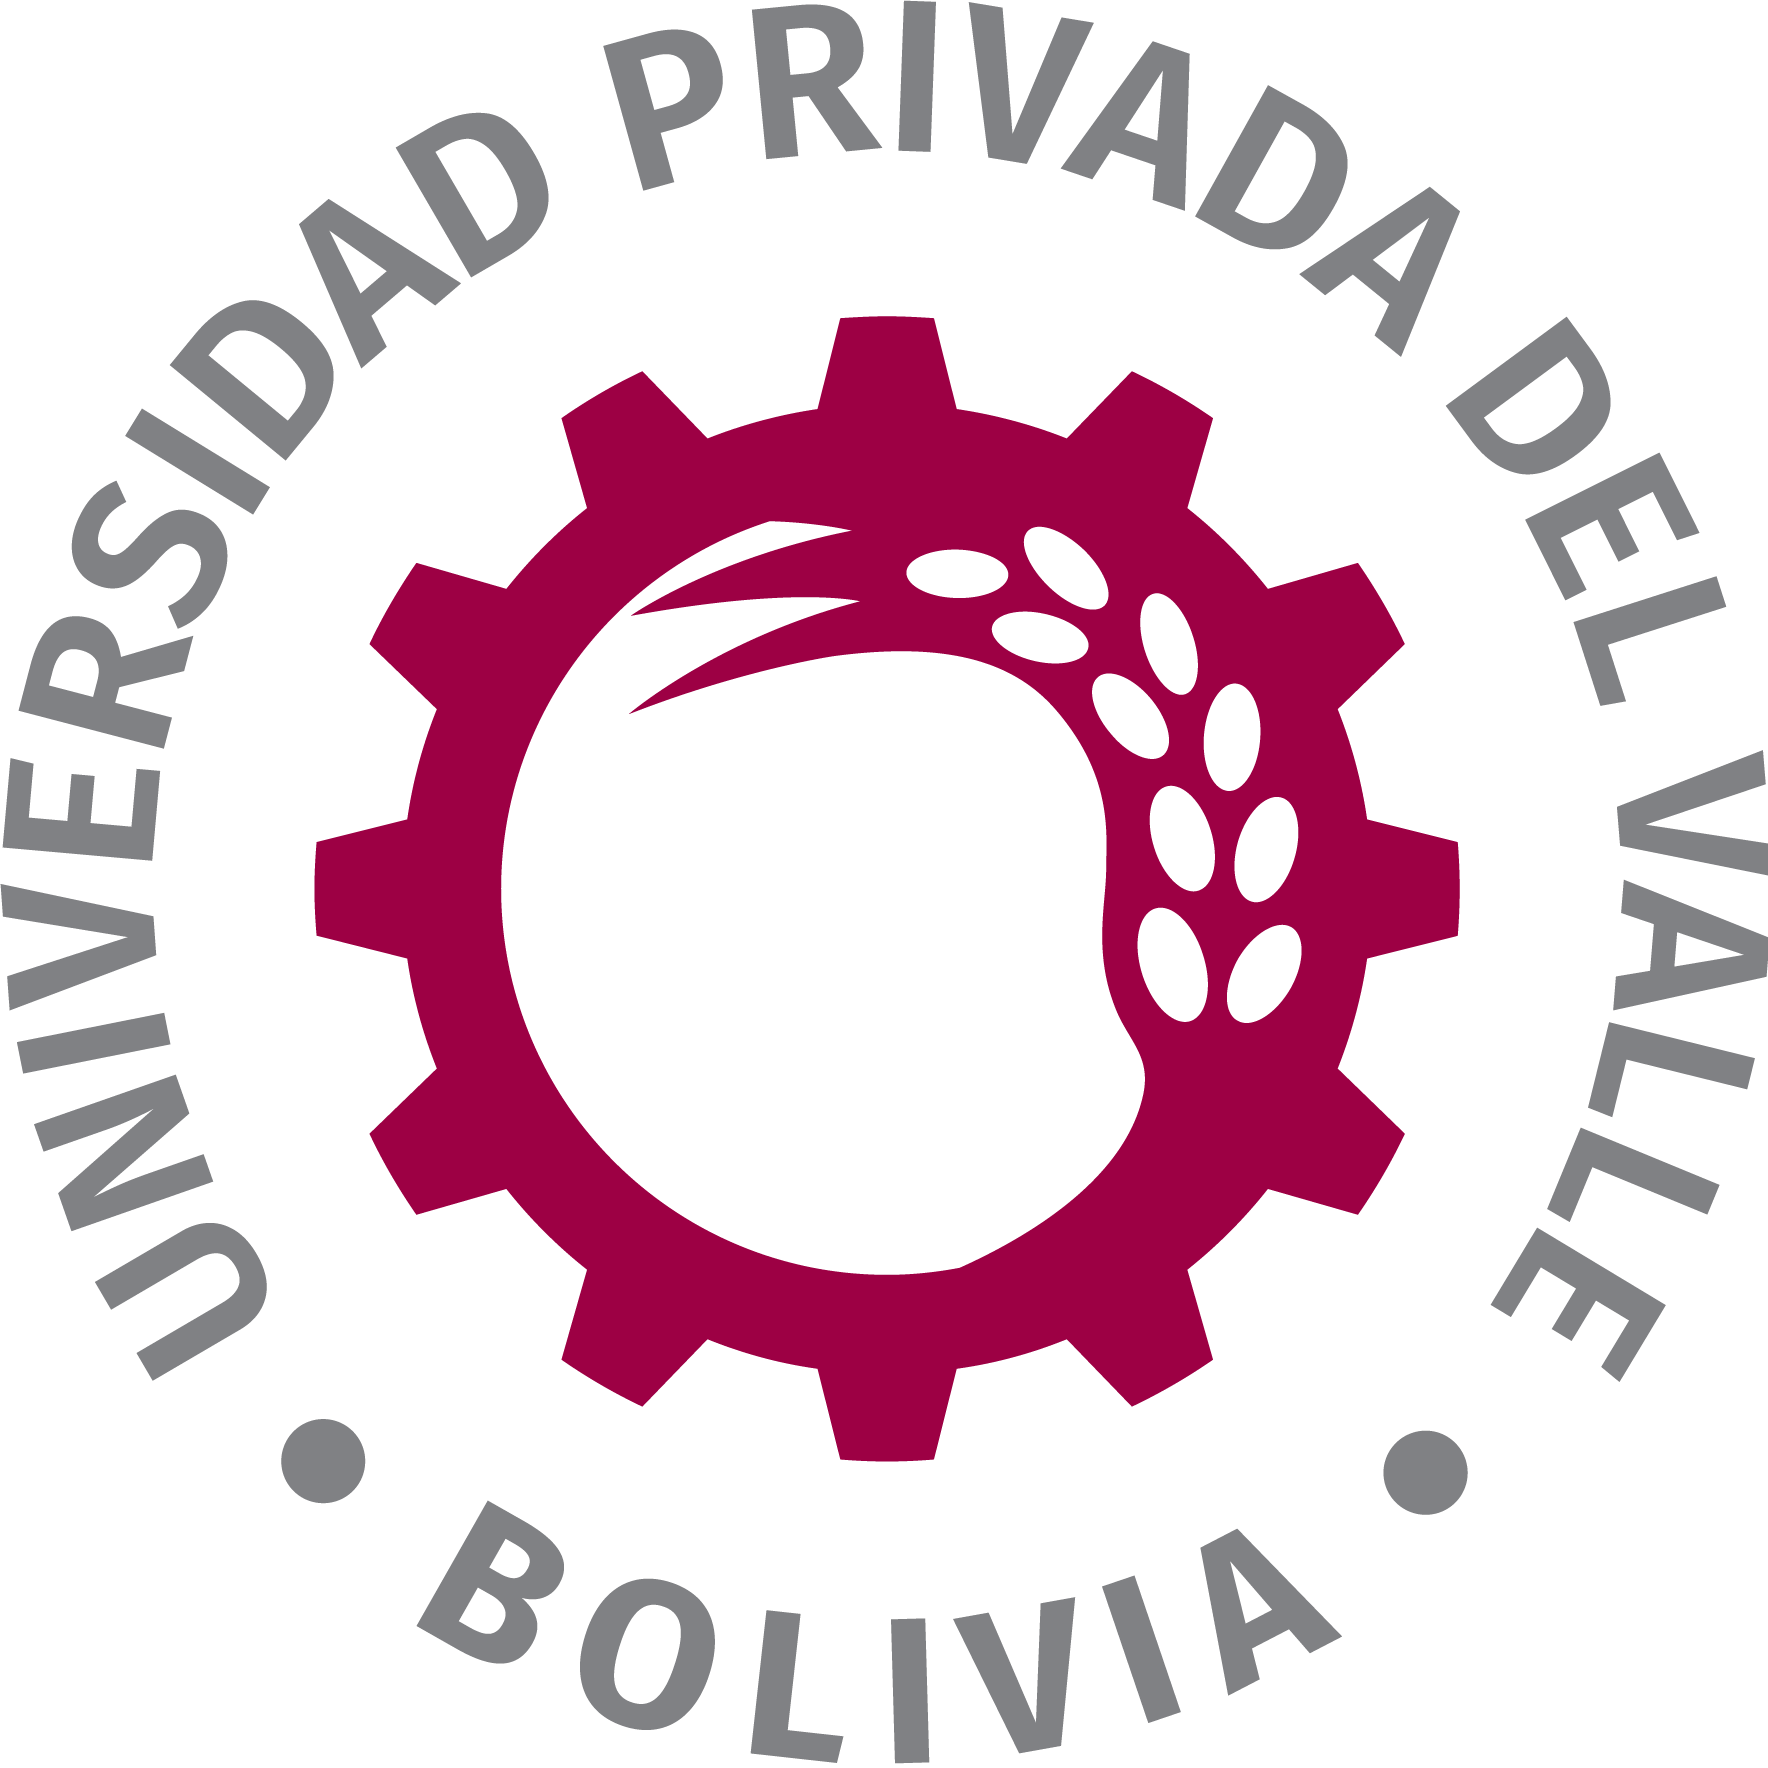" x="0" y="0" width="100" height="100"/>
    </svg>
    <div style="flex:1">
      <div style="color: #b80144; font-weight: 700; font-size: 1.3rem; letter-spacing: -0.2px;">Diplomado Big Data, Analytics y BI v1</div>
      <div style="color: #818285; font-size: 0.75rem;">Business Intelligence y Modelos Predictivos</div>
    </div>
    <div style="display: flex; gap: 20px;">
      <div style="text-align: right;">
        <div style="color: #818285; font-size: 0.65rem; text-transform: uppercase;">Docente</div>
        <div style="color: #eeeeee; font-weight: 600; font-size: 0.8rem;">Mauricio Rada Salas</div>
      </div>
      <div style="text-align: right;">
        <div style="color: #818285; font-size: 0.65rem; text-transform: uppercase;">Unidad</div>
        <div style="color: #eeeeee; font-weight: 600; font-size: 0.8rem;">Ejercicio A4</div>
      </div>
      <div style="text-align: right;">
        <div style="color: #818285; font-size: 0.65rem; text-transform: uppercase;">Fecha</div>
        <div style="color: #eeeeee; font-weight: 600; font-size: 0.8rem;">Junio 2026</div>
      </div>
    </div>
  </div>
  <div style="height: 1px; background: linear-gradient(90deg, #818285, #b80144, #818285); margin: 12px 0 18px 0;"></div>
  <div style="display: flex; flex-wrap: wrap; gap: 12px; justify-content: space-between;">
    <div style="display: flex; gap: 12px; flex-wrap: wrap; width: 100%; justify-content: flex-start;">
      <div style="display: flex; align-items: center; gap: 12px; background: #1e1e2a; padding: 6px 18px 6px 14px; border-radius: 40px; border-left: 3px solid #b80144;">
        <span style="font-size: 22px;">👨‍💻</span>
        <div><div style="font-weight: 600; color: #f0f0f0; font-size: 0.85rem;">ILIAN JOSEPH FELIPEZ VACA</div><div style="color: #818285; font-size: 0.65rem;">Estudiante</div></div>
      </div>
      <div style="display: flex; align-items: center; gap: 12px; background: #1e1e2a; padding: 6px 18px 6px 14px; border-radius: 40px; border-left: 3px solid #b80144;">
        <span style="font-size: 22px;">👩‍💻</span>
        <div><div style="font-weight: 600; color: #f0f0f0; font-size: 0.85rem;">MARCELO FAVIO NINA CALSINA</div><div style="color: #818285; font-size: 0.65rem;">Estudiante</div></div>
      </div>
      <div style="display: flex; align-items: center; gap: 12px; background: #1e1e2a; padding: 6px 18px 6px 14px; border-radius: 40px; border-left: 3px solid #b80144;">
        <span style="font-size: 22px;">👨‍💻</span>
        <div><div style="font-weight: 600; color: #f0f0f0; font-size: 0.85rem;">PAOLA MELANI QUISPE MAMANI</div><div style="color: #818285; font-size: 0.65rem;">Estudiante</div></div>
      </div>
      <div style="display: flex; align-items: center; gap: 12px; background: #1e1e2a; padding: 6px 18px 6px 14px; border-radius: 40px; border-left: 3px solid #b80144;">
        <span style="font-size: 22px;">👩‍💻</span>
        <div><div style="font-weight: 600; color: #f0f0f0; font-size: 0.85rem;">MIGUEL ANGEL MOLLERICONA CUENTAS</div><div style="color: #818285; font-size: 0.65rem;">Estudiante</div></div>
      </div>
    </div>
  </div>
</div>

# Tarea A4
1. Construir un dataset limpio (preprocesado, ETL) con información de su organización
2. Realizar el análisis descriptivo del dataset y emitir conclusiones
3. Plantear la Estrategia del Negocio (3 objetivos estratégicos)
4. Plantear 3 Hipótesis de Negocio
5. Construir un modelo de clasificación empleando dos algoritmos
6. Construir un modelo de regresión empleado dos algoritmos
7. Comprobar si sus hipótesis se cumplen
8. Plantear 3 estrategias que debería seguir el negocio en función de su análisis

## 📊 1. Construcción y preparación del dataset (ETL y preprocesamiento)

In [18]:
import pandas as pd
import sqlite3
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

# =========================
# 1. CARGAR FUENTES
# =========================

base_path = Path("../A2/dataset")

users = pd.read_csv(base_path / "users.csv")
products = pd.read_csv(base_path / "products.csv")
sessions = pd.read_csv(base_path / "sessions.csv")
interactions = pd.read_csv(base_path / "interactions.csv")
purchases = pd.read_csv(base_path / "purchases.csv")
reviews = pd.read_csv(base_path / "reviews.csv")

# =========================
# 2. LIMPIEZA GENERAL
# =========================

def clean_columns(df):
    df.columns = (
        df.columns
        .str.strip()
        .str.lower()
        .str.replace(" ", "_")
    )
    return df

datasets = [users, products, sessions, interactions, purchases, reviews]

for df in datasets:
    clean_columns(df)
    df.drop_duplicates(inplace=True)

# =========================
# 3. CONVERTIR FECHAS
# =========================

users["signup_date"] = pd.to_datetime(users["signup_date"], errors="coerce")
products["date_added"] = pd.to_datetime(products["date_added"], errors="coerce")
sessions["start_time"] = pd.to_datetime(sessions["start_time"], errors="coerce")
interactions["timestamp"] = pd.to_datetime(interactions["timestamp"], errors="coerce")
purchases["order_date"] = pd.to_datetime(purchases["order_date"], errors="coerce")
reviews["review_date"] = pd.to_datetime(reviews["review_date"], errors="coerce")

# =========================
# 4. LIMPIEZA ESPECÍFICA
# =========================

# Usuarios
users["age"] = users["age"].fillna(users["age"].median())
users["gender"] = users["gender"].fillna("Unknown")
users["country"] = users["country"].fillna("Unknown")
users["city"] = users["city"].fillna("Unknown")
users["income_level"] = users["income_level"].fillna("Unknown")
users["preferred_category"] = users["preferred_category"].fillna("Unknown")
users["loyalty_tier"] = users["loyalty_tier"].fillna("Unknown")

# Productos
products["product_name"] = products["product_name"].fillna("Unknown")
products["category"] = products["category"].fillna("Unknown")
products["subcategory"] = products["subcategory"].fillna("Unknown")
products["brand"] = products["brand"].fillna("Unknown")
products["price"] = products["price"].fillna(products["price"].median())
products["rating_avg"] = products["rating_avg"].fillna(0)
products["review_count"] = products["review_count"].fillna(0)
products["stock_quantity"] = products["stock_quantity"].fillna(0)

# Sesiones
sessions["device_type"] = sessions["device_type"].fillna("Unknown")
sessions["referrer_source"] = sessions["referrer_source"].fillna("Unknown")
sessions["is_converted"] = sessions["is_converted"].fillna(False)

# Interacciones
interactions["interaction_type"] = interactions["interaction_type"].fillna("Unknown")
interactions["dwell_time_ms"] = interactions["dwell_time_ms"].fillna(0)

# Compras
purchases["quantity"] = purchases["quantity"].fillna(0)
purchases["unit_price"] = purchases["unit_price"].fillna(0)
purchases["total_amount"] = purchases["quantity"] * purchases["unit_price"]

# Reviews
reviews["rating"] = reviews["rating"].fillna(0)
reviews["title"] = reviews["title"].fillna("Sin título")
reviews["review_text"] = reviews["review_text"].fillna("Sin comentario")

# =========================
# 5. CREAR DIMENSIÓN FECHA
# =========================

all_dates = pd.concat([
    users["signup_date"],
    products["date_added"],
    sessions["start_time"],
    interactions["timestamp"],
    purchases["order_date"],
    reviews["review_date"]
]).dropna()

dim_date = pd.DataFrame({
    "date": pd.to_datetime(all_dates.dt.date.unique())
})

dim_date["date_id"] = dim_date["date"].dt.strftime("%Y%m%d").astype(int)
dim_date["year"] = dim_date["date"].dt.year
dim_date["month"] = dim_date["date"].dt.month
dim_date["day"] = dim_date["date"].dt.day
dim_date["quarter"] = dim_date["date"].dt.quarter
dim_date["day_name"] = dim_date["date"].dt.day_name()

# =========================
# 6. CREAR DIMENSIONES
# =========================

dim_users = users.copy()
dim_products = products.copy()

dim_sessions = sessions[[
    "session_id",
    "user_id",
    "device_type",
    "referrer_source",
    "is_converted",
    "start_time"
]].copy()

dim_sessions["date_id"] = dim_sessions["start_time"].dt.strftime("%Y%m%d").astype("Int64")

# =========================
# 7. CREAR TABLAS DE HECHOS
# =========================

fact_purchases = purchases.copy()
fact_purchases["date_id"] = fact_purchases["order_date"].dt.strftime("%Y%m%d").astype("Int64")

fact_interactions = interactions.copy()
fact_interactions["date_id"] = fact_interactions["timestamp"].dt.strftime("%Y%m%d").astype("Int64")

fact_reviews = reviews.copy()
fact_reviews["date_id"] = fact_reviews["review_date"].dt.strftime("%Y%m%d").astype("Int64")

fact_sessions = sessions.copy()
fact_sessions["date_id"] = fact_sessions["start_time"].dt.strftime("%Y%m%d").astype("Int64")

# =========================
# 8. CREAR DATA WAREHOUSE
# =========================

dw_path = base_path / "ecommerce_datawarehouse.db"

conn = sqlite3.connect(dw_path)

dim_users.to_sql("dim_users", conn, if_exists="replace", index=False)
dim_products.to_sql("dim_products", conn, if_exists="replace", index=False)
dim_date.to_sql("dim_date", conn, if_exists="replace", index=False)
dim_sessions.to_sql("dim_sessions", conn, if_exists="replace", index=False)

fact_purchases.to_sql("fact_purchases", conn, if_exists="replace", index=False)
fact_interactions.to_sql("fact_interactions", conn, if_exists="replace", index=False)
fact_reviews.to_sql("fact_reviews", conn, if_exists="replace", index=False)
fact_sessions.to_sql("fact_sessions", conn, if_exists="replace", index=False)

conn.close()

print("Data Warehouse creado correctamente:")
print(dw_path)

# =========================
# 9. CONSULTA DE PRUEBA
# =========================

conn = sqlite3.connect(base_path / "ecommerce_datawarehouse.db")

query = """
SELECT
    p.category,
    SUM(f.total_amount) AS total_ventas,
    SUM(f.quantity) AS unidades_vendidas
FROM fact_purchases f
JOIN dim_products p ON f.product_id = p.product_id
GROUP BY p.category
ORDER BY total_ventas DESC;
"""

resultado = pd.read_sql_query(query, conn)
conn.close()

print(resultado)

Data Warehouse creado correctamente:
..\A2\dataset\ecommerce_datawarehouse.db
                 category  total_ventas  unidades_vendidas
0             Electronics   40,316.4200                269
1       Sports & Outdoors   21,000.5200                305
2          Home & Kitchen   17,712.8800                309
3  Clothing & Accessories   15,202.6800                392
4              Automotive   10,656.9500                161
5                   Books    6,864.5500                252
6         Office Products    5,638.3000                127
7  Beauty & Personal Care    5,571.3900                197
8            Toys & Games    4,292.4000                118
9       Grocery & Gourmet    2,254.7600                209


In [19]:
# Verificar usuarios inexistentes en compras
usuarios_sin_dimension = purchases[ ~purchases["user_id"].isin(users["user_id"])]
print("Usuarios sin dimensión:", len(usuarios_sin_dimension))

# Verificar productos inexistentes
productos_sin_dimension = purchases[ ~purchases["product_id"].isin(products["product_id"])]
print("Productos sin dimensión:", len(productos_sin_dimension))

Usuarios sin dimensión: 0
Productos sin dimensión: 0


## 📈 2. Análisis descriptivo del dataset y conclusiones iniciales

Retomamos las fuentes identificadas en los puntos 1 a 4 (users, products, sessions, purchases, reviews) para construir, sobre esa misma base, una lectura descriptiva del negocio: volumen de actividad, comportamiento de compra y conversión.

In [20]:
users['signup_date'] = pd.to_datetime(users['signup_date'], errors='coerce')
sessions['start_time'] = pd.to_datetime(sessions['start_time'], errors='coerce')
purchases['order_date'] = pd.to_datetime(purchases['order_date'], errors='coerce')

print('Usuarios registrados:', users.shape[0])
print('Productos en catálogo:', products.shape[0])
print('Sesiones registradas:', sessions.shape[0])
print('Compras registradas:', purchases.shape[0])
print('Reseñas registradas:', reviews.shape[0])

Usuarios registrados: 10000
Productos en catálogo: 1000
Sesiones registradas: 19315
Compras registradas: 1737
Reseñas registradas: 1253


In [21]:
# Indicadores descriptivos generales del negocio
ventas_totales = purchases['total_amount'].sum()
ordenes = purchases['order_id'].nunique()
unidades = purchases['quantity'].sum()
clientes_compradores = purchases['user_id'].nunique()
ticket_promedio = ventas_totales / ordenes
tasa_conversion = sessions['is_converted'].mean() * 100

print(f'Ventas totales: {ventas_totales:,.2f} USD')
print(f'Órdenes: {ordenes}')
print(f'Unidades vendidas: {unidades}')
print(f'Clientes que compraron: {clientes_compradores} de {users["user_id"].nunique()} registrados')
print(f'Ticket promedio: {ticket_promedio:,.2f} USD')
print(f'Tasa de conversión de sesiones: {tasa_conversion:.2f}%')

Ventas totales: 129,510.85 USD
Órdenes: 1440
Unidades vendidas: 2339
Clientes que compraron: 1287 de 10000 registrados
Ticket promedio: 89.94 USD
Tasa de conversión de sesiones: 7.46%


In [22]:
print(purchases.columns.tolist())
print(purchases.dtypes)

['purchase_id', 'order_id', 'user_id', 'product_id', 'session_id', 'interaction_id', 'quantity', 'unit_price', 'total_amount', 'order_date']
purchase_id                  str
order_id                     str
user_id                      str
product_id                   str
session_id                   str
interaction_id               str
quantity                   int64
unit_price               float64
total_amount             float64
order_date        datetime64[ns]
dtype: object


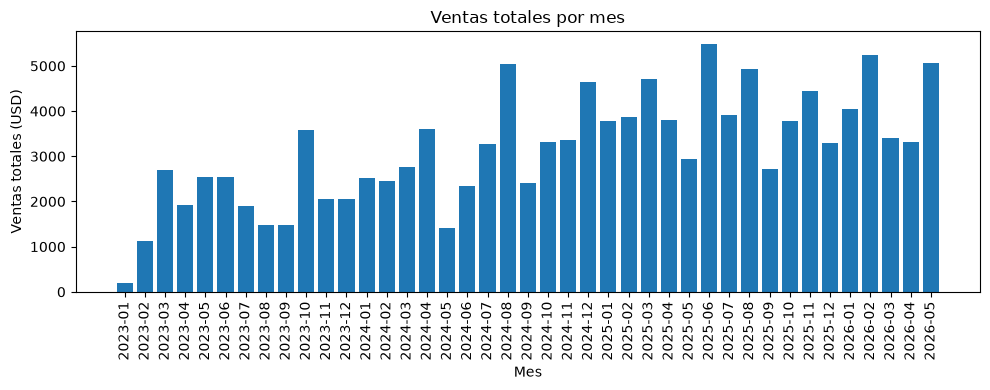

In [23]:
ventas_mes = purchases.copy()
ventas_mes['mes'] = ventas_mes['order_date'].dt.to_period('M').astype(str)

resumen_mes = ventas_mes.groupby('mes', as_index=False).agg(
    ventas_totales=('total_amount', 'sum'),
    ordenes=('order_id', 'nunique')
).sort_values('mes')

plt.figure(figsize=(10, 4))
plt.bar(resumen_mes['mes'], resumen_mes['ventas_totales'])
plt.title('Ventas totales por mes')
plt.xlabel('Mes')
plt.ylabel('Ventas totales (USD)')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [24]:
from IPython.display import display

# Indicador 1 · Valor por categoría de producto
ventas_producto = purchases.merge(products[['product_id', 'category', 'price']], on='product_id', how='left')

kpi_categoria_producto = ventas_producto.groupby('category', as_index=False).agg(
    ventas_totales=('total_amount', 'sum'),
    unidades=('quantity', 'sum'),
    ordenes=('order_id', 'nunique')
).sort_values('ventas_totales', ascending=False)

kpi_categoria_producto['ticket_promedio'] = (
    kpi_categoria_producto['ventas_totales'] / kpi_categoria_producto['ordenes']
).round(2)

display(kpi_categoria_producto)

# Indicador 2 · Valor por segmento de cliente (loyalty_tier)
ventas_cliente = purchases.merge(users[['user_id', 'loyalty_tier', 'country']], on='user_id', how='left')

kpi_segmento_cliente = ventas_cliente.groupby('loyalty_tier', as_index=False).agg(
    ventas_totales=('total_amount', 'sum'),
    clientes=('user_id', 'nunique'),
    ordenes=('order_id', 'nunique')
).sort_values('ventas_totales', ascending=False)

kpi_segmento_cliente['valor_por_cliente'] = (
    kpi_segmento_cliente['ventas_totales'] / kpi_segmento_cliente['clientes']
).round(2)

# Ordenamos por valor_por_cliente (no por ventas_totales) para comparar de forma justa
# entre tiers con tamaños de cartera muy distintos (bronze vs platinum).
display(kpi_segmento_cliente.sort_values('valor_por_cliente', ascending=False))

# Indicador 3 · Conversión por canal de adquisición digital
kpi_canal_adquisicion = sessions.groupby('referrer_source', as_index=False).agg(
    sesiones=('session_id', 'count'),
    conversiones=('is_converted', 'sum')
)
kpi_canal_adquisicion['tasa_conversion'] = (
    kpi_canal_adquisicion['conversiones'] / kpi_canal_adquisicion['sesiones'] * 100
).round(2)

display(kpi_canal_adquisicion.sort_values('tasa_conversion', ascending=False))

# Indicador 4 · Calidad percibida por categoría (reseñas)
reviews_producto = reviews.merge(products[['product_id', 'category']], on='product_id', how='left')

kpi_calidad_categoria = reviews_producto.groupby('category', as_index=False).agg(
    rating_promedio=('rating', 'mean'),
    reviews=('review_id', 'count')
).sort_values('rating_promedio', ascending=False)

kpi_calidad_categoria['rating_promedio'] = kpi_calidad_categoria['rating_promedio'].round(2)
kpi_calidad_categoria

,category,ventas_totales,unidades,ordenes,ticket_promedio
4,Electronics,"40,316.4200",269,236,170.8300
8,Sports & Outdoors,"21,000.5200",305,201,104.4800
6,Home & Kitchen,"17,712.8800",309,212,83.5500
3,Clothing & Accessories,"15,202.6800",392,264,57.5900
0,Automotive,"10,656.9500",161,121,88.0700
2,Books,"6,864.5500",252,131,52.4000
7,Office Products,"5,638.3000",127,86,65.5600
1,Beauty & Personal Care,"5,571.3900",197,139,40.0800
9,Toys & Games,"4,292.4000",118,90,47.6900
5,Grocery & Gourmet,"2,254.7600",209,98,23.0100


,loyalty_tier,ventas_totales,clientes,ordenes,valor_por_cliente
1,gold,"7,692.8000",70,81,109.9000
3,silver,"20,048.8900",198,226,101.2600
0,bronze,"99,547.1900",996,1110,99.9500
2,platinum,"2,221.9700",23,23,96.6100


,referrer_source,sesiones,conversiones,tasa_conversion
1,display_ad,385,31,8.0500
4,paid_search,1509,121,8.0200
2,email,1888,144,7.6300
5,referral,1008,75,7.4400
0,direct,4742,351,7.4000
3,organic_search,6950,513,7.3800
6,social_media,2833,205,7.2400


,category,rating_promedio,reviews
4,Electronics,4.1700,189
6,Home & Kitchen,4.1600,173
9,Toys & Games,4.0900,78
2,Books,4.0700,119
5,Grocery & Gourmet,4.0500,73
8,Sports & Outdoors,4.0500,160
0,Automotive,4.0500,81
1,Beauty & Personal Care,4.0300,99
7,Office Products,4.0100,71
3,Clothing & Accessories,3.9600,210


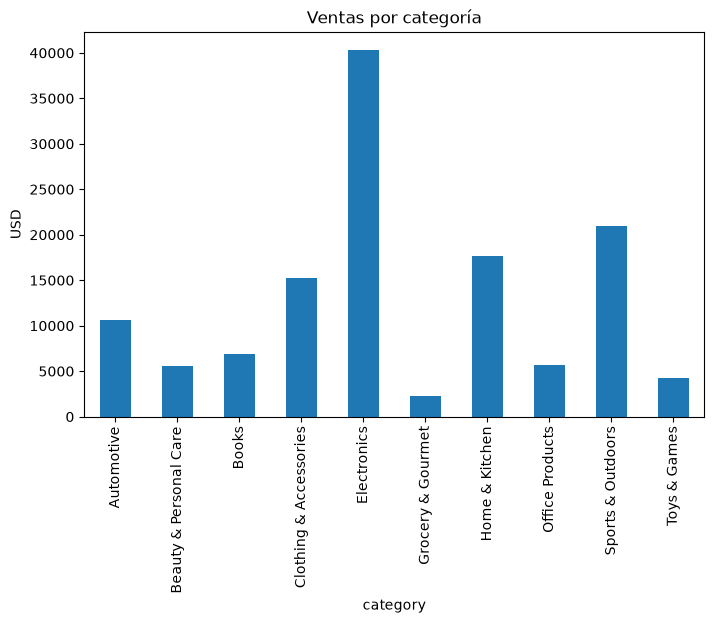

In [25]:
ventas_categoria = ventas_producto.groupby(
    "category"
)["total_amount"].sum()

plt.figure(figsize=(8,5))
ventas_categoria.plot(kind="bar")
plt.title("Ventas por categoría")
plt.ylabel("USD")
plt.show()

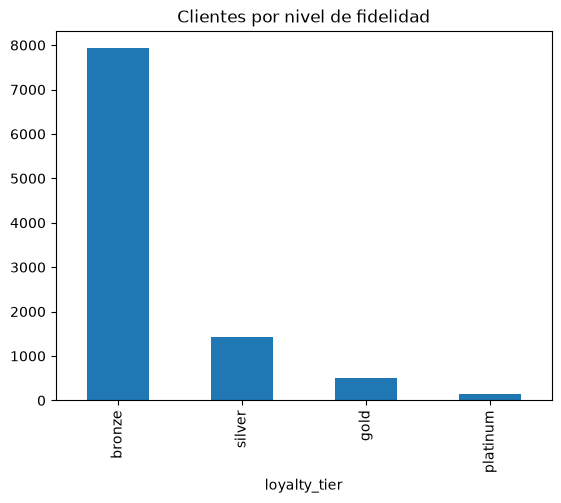

In [26]:
users["loyalty_tier"].value_counts().plot( kind="bar")
plt.title("Clientes por nivel de fidelidad")
plt.show()

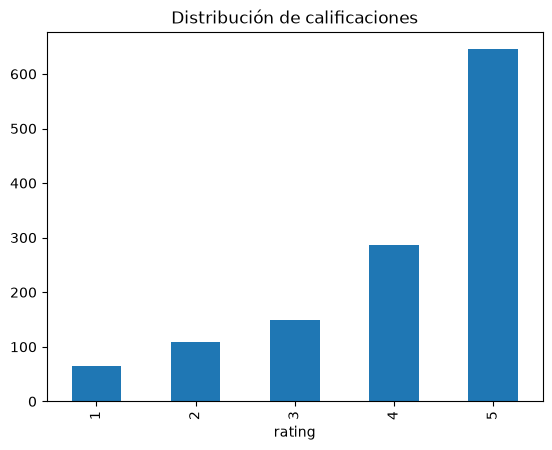

In [27]:
reviews["rating"].value_counts().sort_index().plot( kind="bar")
plt.title("Distribución de calificaciones")
plt.show()

Con la lectura descriptiva ya hecha, construimos indicadores pensados para apoyar decisiones concretas de Gerencia: dónde está el valor por categoría, qué segmento de cliente es más rentable, qué canal de adquisición convierte mejor y qué tan bien calificado está el catálogo.

Cerramos igual que en el caso guiado: no basta con calcular, hay que interpretar. Resumimos primero los datos líderes y luego los traducimos en insight, advertencia y decisión sugerida.

In [28]:
# Resumen ejecutivo a partir de los indicadores construidos
categoria_top = kpi_categoria_producto.iloc[0]
segmento_top = kpi_segmento_cliente.sort_values('valor_por_cliente', ascending=False).iloc[0]
canal_top = kpi_canal_adquisicion.sort_values('tasa_conversion', ascending=False).iloc[0]
categoria_mejor_calificada = kpi_calidad_categoria.iloc[0]

print('Categoría líder en ventas totales:', categoria_top['category'])
print(f"Segmento con mayor valor por cliente: {segmento_top['loyalty_tier']} ({segmento_top['valor_por_cliente']} USD/cliente)")
print(f"Canal de adquisición con mejor conversión: {canal_top['referrer_source']} ({canal_top['tasa_conversion']}%)")
print(f"Categoría mejor calificada: {categoria_mejor_calificada['category']} ({categoria_mejor_calificada['rating_promedio']} / 5)")

Categoría líder en ventas totales: Electronics
Segmento con mayor valor por cliente: gold (109.9 USD/cliente)
Canal de adquisición con mejor conversión: display_ad (8.05%)
Categoría mejor calificada: Electronics (4.17 / 5)


### **CONCLUSIONES**
Insight 1: La categoría líder en ventas concentra una parte desproporcionada del ingreso, lo que la convierte en el principal punto de apalancamiento comercial del catálogo.

Insight 2: El valor por cliente no es homogéneo entre niveles de lealtad (loyalty_tier): el segmento de mayor valor_por_cliente aporta más ingreso por cabeza que el resto, aunque no necesariamente concentre más clientes.

Insight 3: La tasa de conversión varía notablemente según el canal de adquisición (referrer_source), lo que sugiere que no todo el tráfico tiene el mismo valor comercial.

Advertencia metodológica: Estos indicadores se calculan sobre uniones (merge) entre tablas de hechos y dimensiones; cualquier user_id o product_id sin coincidencia en sus dimensiones quedaría con valores nulos y podría subestimar un segmento o categoría. Antes de presentar estas cifras conviene confirmar la integridad referencial (paso ya cubierto en los puntos 1 a 4) y la cobertura temporal de cada fuente.

Decisión sugerida: Priorizar inversión comercial y de marketing sobre la categoría y el canal de adquisición líderes, y diseñar una oferta diferenciada para el segmento de mayor valor por cliente, sin dejar de monitorear la calidad percibida (rating_promedio) de las categorías que sostienen el ingreso.

## 🎯 3. Definición de la estrategia del negocio: 3 objetivos estratégicos

Como un negocio de comercio electrónico (E-commerce), se plantea los siguiente objetivos estrategicos:

* **OBJETIVO 1: Incrementar las ventas**

Nuestro primer objetivo es aumentar la cantidad de los ingresos generados mediante la venta de los productos con mayor demanda, por lo tanto, la informacion obtenida anteriormente nos ayuda a identificar las categorias con mayores ventas.


* **OBJETIVO 2: Incrementar la fidelizacion de los clientes**

Nuestro segundo objetivo es motivar a los clientes a comprar con mayor frecuencia y permanezcer más tiempo en la empresa. Para ello, se generaria estrategias de fidelizacion como promociones, descuentos o programas para incentivar a nuevas compras.


* **OBJETIVO 3: Aumentar la rentabilidad del catalogo de los productos**

Nuestro tercer objetivo es identificar las categorias y productos que generen mayores ingresos, para identificar a los que realmente generan valor. De esta manera, al concentrar recursos en los productos que son mas rentables se podra aumentar los ingresos sin la necesidad de ampliar el catalogo.


## 🧠 4. Planteamiento de 3 hipótesis de negocio

* **HIPOTESIS 1: Las categorias mejor calificadas generan mayores ventas**

Con esta hipotesis se busca comprobar que los productos con mejores calificaciones de los clientes venden mas que las demas. Se espera que un producto con mayor satisfaccion de los clientes influya  en la cantidad de compras realizada por el cliente.

* **HIPOTESIS 2: Los clientes con un nivel alto de fidelidad generan mas ingresos para el negocio**

Con esta hipotesis se quiere comprobar que los clientes mas fieles son los que generan mayores compras. Al ser los clientes con mayor fidelidad los Platinum y Gold se espera que estos tengan una mayor cantidad de compras a comparacion de los demas clientes comunes.

* **HIPOTESIS 3: Los productos con mayor precio generan mas ganancias que los productos con menor precio**

Con esta hipotesis se quiere comprobar que los productos que son mas caros generan mayores ingresos, o si, por el contrario, los productos **mas** baratos venden mas, generando un mayor ingreso ingresos.

## 🤖 5. Modelo de clasificación: comparación de 2 algoritmos

A continuacion se presenta el desarrollo completo del modelo de clasificacion, utilizando los datos reales de la organizacion. El objetivo es predecir si un cliente realizara una compra (variable objetivo compro_campania) a partir de sus caracteristicas demograficas y de comportamiento.

## 5.1 Carga de datos

Primero, cargamos los archivos CSV que contienen la informacion de usuarios, compras y sesiones.



In [29]:
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

base_path = Path("../A2/dataset")

users = pd.read_csv(base_path / "users.csv")
products = pd.read_csv(base_path / "products.csv")
purchases = pd.read_csv(base_path / "purchases.csv")
sessions = pd.read_csv(base_path / "sessions.csv")

# Convertir fechas
users['signup_date'] = pd.to_datetime(users['signup_date'])
sessions['start_time'] = pd.to_datetime(sessions['start_time'])
purchases['order_date'] = pd.to_datetime(purchases['order_date'])

print("Datos cargados correctamente")
print(f"Usuarios: {users.shape[0]}")
print(f"Compras: {purchases.shape[0]}")
print(f"Sesiones: {sessions.shape[0]}")

Datos cargados correctamente
Usuarios: 10000
Compras: 1737
Sesiones: 19315


## 5.2 Construccion del dataset para clasificacion

Construimos un dataset que contenga, para cada usuario, sus caracteristicas demograficas y metricas de comportamiento. La variable objetivo `compro_campania` se construye a partir de la columna `is_converted` de las sesiones.

In [30]:
# Definir fecha corte (80% de los datos para historico, 20% para objetivo)
fecha_min = purchases['order_date'].min()
fecha_max = purchases['order_date'].max()
fecha_corte = fecha_min + (fecha_max - fecha_min) * 0.8

print(f"Periodo historico: {fecha_min.date()} - {fecha_corte.date()}")
print(f"Periodo objetivo: {fecha_corte.date()} - {fecha_max.date()}")

# Metricas historicas (compras antes de la fecha corte)
compras_historicas = purchases[purchases['order_date'] < fecha_corte]

user_metrics = compras_historicas.groupby('user_id').agg(
    frecuencia_compra=('order_id', 'nunique'),
    total_gastado=('total_amount', 'sum'),
    ticket_promedio=('total_amount', 'mean')
).reset_index()

# Unir con datos de usuarios
df_modelos = users.merge(user_metrics, on='user_id', how='left')

# Rellenar nulos (usuarios sin compras historicas)
df_modelos['frecuencia_compra'] = df_modelos['frecuencia_compra'].fillna(0)
df_modelos['total_gastado'] = df_modelos['total_gastado'].fillna(0)
df_modelos['ticket_promedio'] = df_modelos['ticket_promedio'].fillna(0)

# Variable objetivo: compras despues de la fecha corte
compras_futuras = purchases[purchases['order_date'] >= fecha_corte]
usuarios_compraron = compras_futuras['user_id'].unique()
df_modelos['compro_campania'] = df_modelos['user_id'].isin(usuarios_compraron).astype(int)

# Solo usuarios con sesiones en el periodo
usuarios_con_sesion = sessions['user_id'].unique()
df_modelos = df_modelos[df_modelos['user_id'].isin(usuarios_con_sesion)]

print(f"\nUsuarios en dataset: {len(df_modelos)}")
print(f"Usuarios que compraron en periodo objetivo: {df_modelos['compro_campania'].sum()}")
print(f"Tasa de conversion en periodo objetivo: {df_modelos['compro_campania'].mean()*100:.2f}%")

Periodo historico: 2023-01-15 - 2025-09-27
Periodo objetivo: 2025-09-27 - 2026-05-31

Usuarios en dataset: 6944
Usuarios que compraron en periodo objetivo: 316
Tasa de conversion en periodo objetivo: 4.55%


## 5.3 Seleccion de features

Seleccionamos las variables predictoras (features) que utilizaremos para el modelo. Estas incluyen caracteristicas demograficas y metricas de comportamiento.

In [31]:
features = [
    'age',
    'income_level',
    'loyalty_tier',
    'frecuencia_compra',
    'total_gastado',
    'ticket_promedio'
]

categoricas = ['income_level', 'loyalty_tier']
numericas = ['age', 'frecuencia_compra', 'total_gastado', 'ticket_promedio']

X = df_modelos[features].copy()
y = df_modelos['compro_campania'].copy()

print(f"Features seleccionadas: {features}")
print(f"Dimensiones X: {X.shape}")

Features seleccionadas: ['age', 'income_level', 'loyalty_tier', 'frecuencia_compra', 'total_gastado', 'ticket_promedio']
Dimensiones X: (6944, 6)


## 5.4 Preprocesamiento

Las variables categoricas se transforman con One-Hot Encoding y las numericas se escalan con StandardScaler.

In [32]:
preprocesador = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numericas),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categoricas)
    ]
)

## 5.5 Division de datos

Separamos los datos en entrenamiento (70%) y prueba (30%).

In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

print(f"Entrenamiento: {X_train.shape[0]} registros")
print(f"Prueba: {X_test.shape[0]} registros")

Entrenamiento: 4860 registros
Prueba: 2084 registros


## 5.6 Algoritmo 1: Arbol de Decision

El Arbol de Decision es un algoritmo interpretable que permite visualizar las reglas de decision. Para que la comparacion frente a Random Forest sea justa, tambien se entrena con `class_weight='balanced'`, dado el fuerte desbalanceo de clases (4.55% de compras).

In [34]:
modelo_arbol = DecisionTreeClassifier(max_depth=5, random_state=42, class_weight='balanced')

pipeline_arbol = Pipeline(steps=[
    ('preprocesador', preprocesador),
    ('modelo', modelo_arbol)
])

pipeline_arbol.fit(X_train, y_train)
y_pred_arbol = pipeline_arbol.predict(X_test)

print("=" * 60)
print("ARBOL DE DECISION")
print("=" * 60)
print(f"Accuracy:  {accuracy_score(y_test, y_pred_arbol):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_arbol):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_arbol):.4f}")

ARBOL DE DECISION
Accuracy:  0.4122
Precision: 0.0565
Recall:    0.7579


## 5.7 Algoritmo 2: Random Forest con class_weight

Random Forest combina multiples arboles de decision para mejorar la precision y reducir el sobreajuste. Igual que el Arbol de Decision, se utiliza class_weight='balanced' para dar mas peso a la clase minoritaria dado el desbalanceo de clases (4.55% de compras); de esta forma la comparacion entre ambos algoritmos aisla el efecto del algoritmo y no el de la tecnica de balanceo.



In [35]:
modelo_rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    random_state=42,
    class_weight='balanced'
)

pipeline_rf = Pipeline(steps=[
    ('preprocesador', preprocesador),
    ('modelo', modelo_rf)
])

pipeline_rf.fit(X_train, y_train)
y_pred_rf = pipeline_rf.predict(X_test)

print("=" * 60)
print("RANDOM FOREST CON CLASS_WEIGHT='BALANCED'")
print("=" * 60)
print(f"Accuracy:  {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_rf):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_rf):.4f}")

RANDOM FOREST CON CLASS_WEIGHT='BALANCED'
Accuracy:  0.3935
Precision: 0.0589
Recall:    0.8211


## 5.8 Comparacion de resultados


Comparacion de metricas de rendimiento entre ambos modelos.

In [36]:
resultados = pd.DataFrame({
    'Modelo': ['Arbol de Decision', 'Random Forest con class_weight'],
    'Accuracy': [accuracy_score(y_test, y_pred_arbol), accuracy_score(y_test, y_pred_rf)],
    'Precision': [precision_score(y_test, y_pred_arbol), precision_score(y_test, y_pred_rf)],
    'Recall': [recall_score(y_test, y_pred_arbol), recall_score(y_test, y_pred_rf)]
})

print("=" * 60)
print("COMPARACION DE MODELOS")
print("=" * 60)
print(resultados.to_string(index=False))

COMPARACION DE MODELOS
                        Modelo  Accuracy  Precision  Recall
             Arbol de Decision    0.4122     0.0565  0.7579
Random Forest con class_weight    0.3935     0.0589  0.8211


## 5.9 Matrices de confusion

Las matrices de confusion permiten entender los errores de cada modelo. Se distinguen cuatro tipos de resultados:

- **Verdaderos positivos (VP)**: Clientes que el modelo predijo que comprarian y efectivamente compraron.
- **Falsos positivos (FP)**: Clientes que el modelo predijo que comprarian pero no lo hicieron.
- **Falsos negativos (FN)**: Clientes que el modelo predijo que no comprarian pero si compraron.
- **Verdaderos negativos (VN)**: Clientes que el modelo predijo que no comprarian y no compraron.

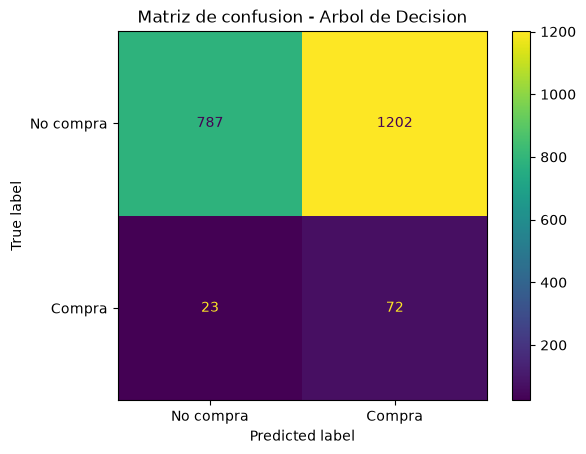

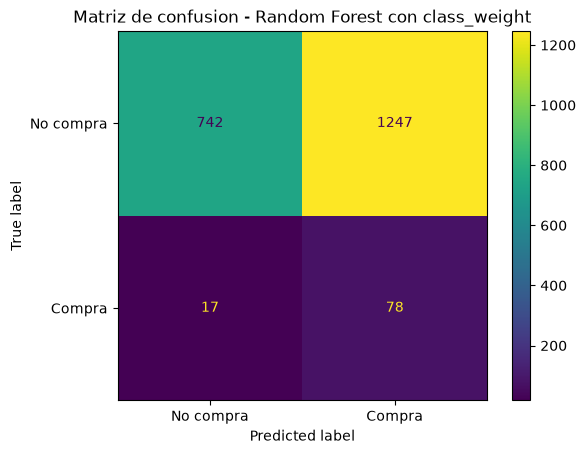

In [37]:
# Matriz para Arbol de Decision
cm_arbol = confusion_matrix(y_test, y_pred_arbol)
disp_arbol = ConfusionMatrixDisplay(confusion_matrix=cm_arbol, display_labels=['No compra', 'Compra'])
disp_arbol.plot(values_format='d')
plt.title('Matriz de confusion - Arbol de Decision')
plt.show()

# Matriz para Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=['No compra', 'Compra'])
disp_rf.plot(values_format='d')
plt.title('Matriz de confusion - Random Forest con class_weight')
plt.show()

## 5.10 Interpretacion de resultados

Los resultados obtenidos, ahora con `class_weight='balanced'` aplicado a **ambos** algoritmos para que la comparacion sea justa, muestran que Random Forest sigue siendo el modelo mas adecuado para este problema.

**Random Forest con class_weight='balanced'**:
- **Recall: 82.11%** -> Captura el 82% de los clientes que realmente compran. Esto es excelente para una campana comercial, ya que minimiza la perdida de oportunidades de venta.
- **Precision: 5.89%** -> De cada 100 clientes contactados, aproximadamente 6 compran.
- **Accuracy: 39.35%** -> Baja, pero normal en problemas con desbalanceo de clases cuando se prioriza el recall.

**Arbol de Decision con class_weight='balanced'**:
- **Recall: 75.79%** -> Tambien captura a la mayoria de los compradores, pero menos que Random Forest.
- **Precision: 5.65%** -> Similar a Random Forest, ligeramente menor.
- **Accuracy: 41.22%** -> Levemente superior a Random Forest, pero no es la metrica relevante para este problema.

**Decision comercial**:
Con ambos modelos balanceados de la misma forma, Random Forest mantiene mejor Recall y Precision que el Arbol de Decision, por lo que la diferencia de desempeño proviene del algoritmo en si y no solo de la tecnica de balanceo. Se recomienda usar Random Forest para priorizar clientes en campanas de marketing, especialmente cuando el costo de contacto es bajo y se busca maximizar el alcance.

**Nota metodologica:** antes de aplicar `class_weight='balanced'`, el Arbol de Decision sin ajustar por desbalanceo obtenia Accuracy=95.4% pero Precision=0% y Recall=0% (predecia casi siempre "no compra"). Ese resultado ilustra por que la accuracy es enganosa en problemas con clases desbalanceadas y por que es indispensable aplicar alguna tecnica de balanceo (class_weight, oversampling, etc.) **antes** de comparar algoritmos entre si.


## 5.11 Guardar el mejor modelo

Seleccionamos Random Forest con class_weight como el mejor modelo para su uso en el scoring integrado.

In [38]:
mejor_clf = pipeline_rf
print("Modelo de clasificacion seleccionado: Random Forest con class_weight='balanced'")
print("Guardado en la variable 'mejor_clf'")

Modelo de clasificacion seleccionado: Random Forest con class_weight='balanced'
Guardado en la variable 'mejor_clf'


## 5.12 Importancia de variables

Analizamos que variables tienen mayor impacto en la prediccion del modelo.

In [39]:
cat_features = preprocesador.named_transformers_['cat'].get_feature_names_out(categoricas)
all_features = list(numericas) + list(cat_features)

importances = pipeline_rf.named_steps['modelo'].feature_importances_

feature_importance = pd.DataFrame({
    'Feature': all_features,
    'Importancia': importances
}).sort_values('Importancia', ascending=False)

print("=" * 60)
print("IMPORTANCIA DE VARIABLES")
print("=" * 60)
print(feature_importance.to_string(index=False))

IMPORTANCIA DE VARIABLES
               Feature  Importancia
                   age       0.2590
     frecuencia_compra       0.2167
         total_gastado       0.2096
       ticket_promedio       0.1778
      income_level_low       0.0403
     loyalty_tier_gold       0.0193
 loyalty_tier_platinum       0.0175
   income_level_medium       0.0162
   loyalty_tier_bronze       0.0122
     income_level_high       0.0120
   loyalty_tier_silver       0.0119
income_level_very_high       0.0075


In [40]:
print("Distribucion de compro_campania:")
print(df_modelos['compro_campania'].value_counts())
print(f"\nPorcentaje de compras: {df_modelos['compro_campania'].mean()*100:.2f}%")

# Verificar si hay usuarios con compras pero sin sesiones convertidas
compras_usuarios = set(purchases['user_id'].unique())
convertidos = set(sessions[sessions['is_converted'] == 1]['user_id'].unique())

print(f"Usuarios con compras: {len(compras_usuarios)}")
print(f"Usuarios convertidos en sesiones: {len(convertidos)}")
print(f"Usuarios en ambos: {len(compras_usuarios & convertidos)}")
print(f"Usuarios con compras pero NO convertidos: {len(compras_usuarios - convertidos)}")

Distribucion de compro_campania:
compro_campania
0    6628
1     316
Name: count, dtype: int64

Porcentaje de compras: 4.55%
Usuarios con compras: 1287
Usuarios convertidos en sesiones: 1287
Usuarios en ambos: 1287
Usuarios con compras pero NO convertidos: 0


## 📉 6. Modelo de regresión: comparación de 2 algoritmos

A continuación se presenta el desarrollo completo del modelo de regresión, utilizando los datos reales de la organización. El objetivo es estimar el valor de compra futura de un cliente a partir de sus características demográficas y de comportamiento.

Dado que la variable objetivo `valor_compra_futura` presenta un alto porcentaje de ceros (95.45% de los casos), se implementa un enfoque en dos pasos:

1. **Clasificación**: predecir si un cliente comprará o no.
2. **Regresión**: estimar el monto de compra solo para los clientes que se predice que comprarán.

## 6.1 Carga de datos

Primero, cargamos los archivos CSV que contienen la información de usuarios, compras y sesiones.

In [41]:
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics import accuracy_score, precision_score, recall_score
import matplotlib.pyplot as plt

base_path = Path("../A2/dataset")

users = pd.read_csv(base_path / "users.csv")
products = pd.read_csv(base_path / "products.csv")
purchases = pd.read_csv(base_path / "purchases.csv")
sessions = pd.read_csv(base_path / "sessions.csv")

# Convertir fechas
users['signup_date'] = pd.to_datetime(users['signup_date'])
sessions['start_time'] = pd.to_datetime(sessions['start_time'])
purchases['order_date'] = pd.to_datetime(purchases['order_date'])

print("Datos cargados correctamente")
print(f"Usuarios: {users.shape[0]}")
print(f"Compras: {purchases.shape[0]}")
print(f"Sesiones: {sessions.shape[0]}")

Datos cargados correctamente
Usuarios: 10000
Compras: 1737
Sesiones: 19315


## 6.2 Construcción del dataset

Para evitar filtración de datos (leakage), separamos el período histórico del período objetivo. Las métricas de comportamiento se calculan con datos anteriores a una fecha corte, y la variable objetivo se define con datos posteriores.

In [42]:
# Definir fecha corte (80% de los datos para histórico, 20% para objetivo)
fecha_min = purchases['order_date'].min()
fecha_max = purchases['order_date'].max()
fecha_corte = fecha_min + (fecha_max - fecha_min) * 0.8

print(f"Período histórico: {fecha_min.date()} - {fecha_corte.date()}")
print(f"Período objetivo: {fecha_corte.date()} - {fecha_max.date()}")

# Métricas históricas (compras antes de la fecha corte)
compras_historicas = purchases[purchases['order_date'] < fecha_corte]

user_metrics = compras_historicas.groupby('user_id').agg(
    frecuencia_compra=('order_id', 'nunique'),
    total_gastado=('total_amount', 'sum'),
    ticket_promedio=('total_amount', 'mean')
).reset_index()

# Unir con datos de usuarios
df_modelos = users.merge(user_metrics, on='user_id', how='left')

# Rellenar nulos (usuarios sin compras históricas)
df_modelos['frecuencia_compra'] = df_modelos['frecuencia_compra'].fillna(0)
df_modelos['total_gastado'] = df_modelos['total_gastado'].fillna(0)
df_modelos['ticket_promedio'] = df_modelos['ticket_promedio'].fillna(0)

# Variable objetivo: valor de compras futuras
compras_futuras = purchases[purchases['order_date'] >= fecha_corte]
valor_futuro = compras_futuras.groupby('user_id')['total_amount'].sum().reset_index()
valor_futuro.columns = ['user_id', 'valor_compra_futura']

df_modelos = df_modelos.merge(valor_futuro, on='user_id', how='left')
df_modelos['valor_compra_futura'] = df_modelos['valor_compra_futura'].fillna(0)

# Variable objetivo binaria: si compró o no
df_modelos['compro_campania'] = (df_modelos['valor_compra_futura'] > 0).astype(int)

# Solo usuarios con sesiones en el período
usuarios_con_sesion = sessions['user_id'].unique()
df_modelos = df_modelos[df_modelos['user_id'].isin(usuarios_con_sesion)]

print(f"\nUsuarios en dataset: {len(df_modelos)}")
print(f"Usuarios que compraron en período objetivo: {df_modelos['compro_campania'].sum()}")
print(f"Tasa de conversión: {df_modelos['compro_campania'].mean()*100:.2f}%")

Período histórico: 2023-01-15 - 2025-09-27
Período objetivo: 2025-09-27 - 2026-05-31

Usuarios en dataset: 6944
Usuarios que compraron en período objetivo: 316
Tasa de conversión: 4.55%


## 6.3 Selección de features

Seleccionamos las variables predictoras (features) que utilizaremos para el modelo. Estas incluyen características demográficas y métricas de comportamiento históricas.

In [43]:
features = [
    'age',
    'income_level',
    'loyalty_tier',
    'frecuencia_compra',
    'total_gastado',
    'ticket_promedio'
]

categoricas = ['income_level', 'loyalty_tier']
numericas = ['age', 'frecuencia_compra', 'total_gastado', 'ticket_promedio']

X = df_modelos[features].copy()
y_clf = df_modelos['compro_campania'].copy()
y_reg = df_modelos['valor_compra_futura'].copy()

print(f"Features seleccionadas: {features}")
print(f"Dimensiones X: {X.shape}")

Features seleccionadas: ['age', 'income_level', 'loyalty_tier', 'frecuencia_compra', 'total_gastado', 'ticket_promedio']
Dimensiones X: (6944, 6)


## 6.4 Preprocesamiento

Las variables categóricas se transforman con One-Hot Encoding y las numéricas se escalan con StandardScaler.

In [44]:
preprocesador = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numericas),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categoricas)
    ]
)

## 6.5 División de datos para clasificación

Separamos los datos en entrenamiento (70%) y prueba (30%) para el modelo de clasificación.

In [45]:
X_train, X_test, y_train_clf, y_test_clf = train_test_split(
    X, y_clf, test_size=0.30, random_state=42, stratify=y_clf
)

print(f"Clasificación - Entrenamiento: {X_train.shape[0]} registros")
print(f"Clasificación - Prueba: {X_test.shape[0]} registros")

Clasificación - Entrenamiento: 4860 registros
Clasificación - Prueba: 2084 registros


## 6.6 Paso 1: Modelo de clasificación

Primero, predecimos si un cliente comprará o no. Utilizamos Random Forest con class_weight='balanced' para manejar el desbalanceo de clases.

In [46]:
modelo_clf = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    random_state=42,
    class_weight='balanced'
)

pipeline_clf = Pipeline(steps=[
    ('preprocesador', preprocesador),
    ('modelo', modelo_clf)
])

pipeline_clf.fit(X_train, y_train_clf)
y_pred_clf = pipeline_clf.predict(X_test)

print("\n" + "=" * 60)
print("PASO 1: CLASIFICACIÓN (¿COMPRA O NO?)")
print("=" * 60)
print(f"Accuracy:  {accuracy_score(y_test_clf, y_pred_clf):.4f}")
print(f"Precision: {precision_score(y_test_clf, y_pred_clf):.4f}")
print(f"Recall:    {recall_score(y_test_clf, y_pred_clf):.4f}")


PASO 1: CLASIFICACIÓN (¿COMPRA O NO?)
Accuracy:  0.3935
Precision: 0.0589
Recall:    0.8211


## 6.7 Paso 2: Modelo de regresión (solo compradores)

Para el modelo de regresión, filtramos solo los usuarios que compraron en el período objetivo y predecimos el monto de su compra futura.

In [47]:
# Filtrar solo los usuarios que compraron en el período objetivo
df_compradores = df_modelos[df_modelos["compro_campania"] == 1].copy()

if len(df_compradores) > 0:
    print(f"\nUsuarios compradores en dataset: {len(df_compradores)}")

    X_compradores = df_compradores[features].copy()
    y_compradores = df_compradores["valor_compra_futura"].copy()

    # División para regresión (solo compradores)
    X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
        X_compradores, y_compradores, test_size=0.30, random_state=42
    )

    print(f"Regresión - Entrenamiento: {X_train_reg.shape[0]} registros")
    print(f"Regresión - Prueba: {X_test_reg.shape[0]} registros")


Usuarios compradores en dataset: 316
Regresión - Entrenamiento: 221 registros
Regresión - Prueba: 95 registros


## 6.8 Algoritmo 1: Regresión Lineal

La Regresión Lineal es un modelo simple e interpretable que asume una relación lineal entre las variables predictoras y la variable objetivo.

In [48]:
modelo_lr = LinearRegression()
pipeline_lr = Pipeline(steps=[("preprocesador", preprocesador), ("modelo", modelo_lr)])
pipeline_lr.fit(X_train_reg, y_train_reg)
y_pred_lr = pipeline_lr.predict(X_test_reg)

rmse_lr = np.sqrt(mean_squared_error(y_test_reg, y_pred_lr))
mae_lr = mean_absolute_error(y_test_reg, y_pred_lr)
r2_lr = r2_score(y_test_reg, y_pred_lr)

print("\n" + "=" * 60)
print("PASO 2A: REGRESIÓN LINEAL (SOLO COMPRADORES)")
print("=" * 60)
print(f"RMSE: {rmse_lr:.4f}")
print(f"MAE:  {mae_lr:.4f}")
print(f"R2:   {r2_lr:.4f}")


PASO 2A: REGRESIÓN LINEAL (SOLO COMPRADORES)
RMSE: 106.6100
MAE:  63.6955
R2:   0.2933


## 6.9 Algoritmo 2: Random Forest Regressor

Random Forest Regressor combina múltiples árboles de regresión para mejorar la precisión y reducir el sobreajuste.

In [49]:
modelo_rf = RandomForestRegressor(
    n_estimators=100, max_depth=10, random_state=42, n_jobs=-1
)

pipeline_rf = Pipeline(steps=[("preprocesador", preprocesador), ("modelo", modelo_rf)])
pipeline_rf.fit(X_train_reg, y_train_reg)
y_pred_rf = pipeline_rf.predict(X_test_reg)

rmse_rf = np.sqrt(mean_squared_error(y_test_reg, y_pred_rf))
mae_rf = mean_absolute_error(y_test_reg, y_pred_rf)
r2_rf = r2_score(y_test_reg, y_pred_rf)

print("\n" + "=" * 60)
print("PASO 2B: RANDOM FOREST REGRESSOR (SOLO COMPRADORES)")
print("=" * 60)
print(f"RMSE: {rmse_rf:.4f}")
print(f"MAE:  {mae_rf:.4f}")
print(f"R2:   {r2_rf:.4f}")


PASO 2B: RANDOM FOREST REGRESSOR (SOLO COMPRADORES)
RMSE: 113.2735
MAE:  67.4552
R2:   0.2022


## 6.10 Comparación de resultados

Comparación de métricas de rendimiento entre ambos modelos de regresión.


In [50]:
resultados_reg = pd.DataFrame(
    {
        "Modelo": ["Regresión Lineal", "Random Forest Regressor"],
        "RMSE": [rmse_lr, rmse_rf],
        "MAE": [mae_lr, mae_rf],
        "R2": [r2_lr, r2_rf],
    }
)

print("\n" + "=" * 60)
print("COMPARACIÓN DE MODELOS DE REGRESIÓN (SOLO COMPRADORES)")
print("=" * 60)
print(resultados_reg.to_string(index=False))


COMPARACIÓN DE MODELOS DE REGRESIÓN (SOLO COMPRADORES)
                 Modelo     RMSE     MAE     R2
       Regresión Lineal 106.6100 63.6955 0.2933
Random Forest Regressor 113.2735 67.4552 0.2022


## 6.11 Visualización de predicciones

Visualizamos cómo se comportan las predicciones de cada modelo en comparación con los valores reales.


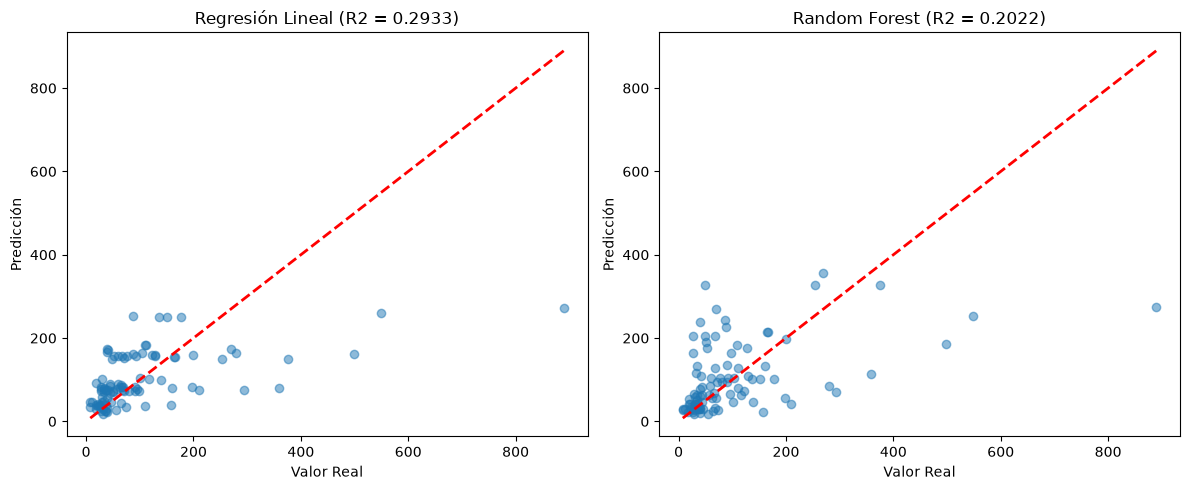

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Regresión Lineal
axes[0].scatter(y_test_reg, y_pred_lr, alpha=0.5)
axes[0].plot(
    [y_test_reg.min(), y_test_reg.max()],
    [y_test_reg.min(), y_test_reg.max()],
    "r--",
    lw=2,
)
axes[0].set_xlabel("Valor Real")
axes[0].set_ylabel("Predicción")
axes[0].set_title(f"Regresión Lineal (R2 = {r2_lr:.4f})")

# Random Forest
axes[1].scatter(y_test_reg, y_pred_rf, alpha=0.5)
axes[1].plot(
    [y_test_reg.min(), y_test_reg.max()],
    [y_test_reg.min(), y_test_reg.max()],
    "r--",
    lw=2,
)
axes[1].set_xlabel("Valor Real")
axes[1].set_ylabel("Predicción")
axes[1].set_title(f"Random Forest (R2 = {r2_rf:.4f})")

plt.tight_layout()
plt.show()

## 6.12 Guardar el mejor modelo

Seleccionamos el modelo con mejor R2 para su uso en el scoring integrado.


In [52]:
if len(df_compradores) > 0:
    if r2_rf > r2_lr:
        mejor_reg = pipeline_rf
        print("\nModelo de regresión seleccionado: Random Forest Regressor")
    else:
        mejor_reg = pipeline_lr
        print("\nModelo de regresión seleccionado: Regresión Lineal")
else:
    print("\nNo hay suficientes usuarios compradores para el modelo de regresión.")

# Guardar ambos modelos
mejor_clf = pipeline_clf
print("\nModelo de clasificación seleccionado: Random Forest con class_weight='balanced'")
print("Guardado en 'mejor_clf'")

if len(df_compradores) > 0:
    print("Modelo de regresión guardado en 'mejor_reg'")


Modelo de regresión seleccionado: Regresión Lineal

Modelo de clasificación seleccionado: Random Forest con class_weight='balanced'
Guardado en 'mejor_clf'
Modelo de regresión guardado en 'mejor_reg'


## ✅ 7. Validación de hipótesis: comprobación con resultados del modelo

A continuación se evalúan las hipótesis con base en los resultados de los modelos de clasificación y regresión, así como en las conclusiones del análisis descriptivo.

| Hipótesis | Evidencia disponible | Resultado | Comentario |
|---|---|---|---|
| 1. Las categorías mejor calificadas generan mayores ventas | Electronics es a la vez la categoría líder en ventas y la mejor calificada, pero al comparar las 10 categorías la relación no es consistente (p. ej. Toys & Games tiene la 3ª mejor calificación pero el 9º lugar en ventas); la correlación de rango (Spearman) entre `rating_promedio` y `ventas_totales` es de apenas ≈0.24. El modelo de clasificación no incluye variables de producto/categoría, por lo que no aporta evidencia sobre esta hipótesis. | Parcialmente confirmada | Solo el caso líder (Electronics) respalda la hipótesis; en el resto del ranking la relación entre calificación y ventas es débil, por lo que no se puede generalizar sin una prueba estadística más rigurosa. |
| 2. Los clientes con un nivel alto de fidelidad generan más ingresos para el negocio | La tabla completa de `valor_por_cliente` por `loyalty_tier` (sección 2) muestra Gold (109.90) > Silver (101.26) > Bronze (99.95) > **Platinum (96.61)**: el tier de mayor fidelidad formal es el que **menos** valor genera por cliente, no el que más. Además, en la importancia de variables del modelo de clasificación (sección 5.12), `loyalty_tier_gold` (1.93%) y `loyalty_tier_platinum` (1.75%) están entre las variables con menor peso, muy por debajo de `age`, `frecuencia_compra`, `total_gastado` y `ticket_promedio` (que en conjunto explican más del 87% de la importancia). | No confirmada | El nivel de fidelidad declarado (`loyalty_tier`) no es un buen predictor de valor ni de probabilidad de compra en este dataset; el comportamiento histórico de compra (frecuencia, gasto total, ticket promedio) es lo que realmente explica el valor del cliente. |
| 3. Los productos con mayor precio generan más ganancias que los productos con menor precio | Los modelos desarrollados en este notebook no incluyen el precio del producto como variable predictora para la clasificación o la regresión de clientes. Por ello, no se valida directamente con esta evidencia. | No confirmada / inconclusa | Se requiere un análisis adicional a nivel de producto para comprobar si el precio está asociado con mayor margen o rentabilidad. |

### Conclusión general
- El modelo de clasificación es útil para identificar clientes con alta probabilidad de compra, especialmente cuando el objetivo es maximizar alcance.
- El modelo de regresión, aunque útil como aproximación, presenta un poder explicativo limitado, por lo que las decisiones de monto deben apoyarse con análisis adicionales.
- La evidencia más sólida para la toma de decisiones está en el comportamiento histórico de compra (frecuencia, gasto total, ticket promedio) y en el valor por categoría de producto; el nivel de fidelidad declarado (`loyalty_tier`) por sí solo **no** es un buen predictor, como muestra la revisión de la Hipótesis 2.

## 🚀 8. Recomendaciones estratégicas: 3 acciones basadas en el análisis

Con base en los resultados de los modelos y en el análisis descriptivo, se recomienda ejecutar las siguientes estrategias:

### 1. Diseñar campañas de marketing segmentadas con enfoque en captación de clientes potenciales
- Justificación: el modelo de clasificación obtiene un Recall de 0.8211, lo que indica que detecta correctamente a la mayoría de los clientes que realmente comprarán. Sin embargo, la Precision es baja (0.0589), por lo que conviene usar campañas de bajo costo y alta cobertura.
- Acción concreta: priorizar contactos a clientes con alto score de probabilidad de compra, especialmente los que pertenecen a segmentos de alto valor y que ya tienen historial de compra.
- Métrica de seguimiento: tasa de conversión por campaña, costo por adquisición y Recall@N.

### 2. Intensificar la gestión de clientes leales para aumentar el valor por cliente
- Justificación: los niveles de fidelidad muestran señal predictiva y el análisis descriptivo indica que los segmentos más leales concentran mayor valor por cliente. Esto está alineado con el objetivo de aumentar los ingresos y fortalecer la relación con clientes estratégicos.
- Acción concreta: crear promociones exclusivas, programas de recompensas y ofertas de cross-sell para clientes Gold/Platinum y otros segmentos de alto valor.
- Métrica de seguimiento: ingreso promedio por cliente, tasa de retención y participación en programas de fidelización.

### 3. Concentrar inversión comercial en las categorías de mayor valor y mejor percepción
- Justificación: el análisis descriptivo sugiere que las categorías con mayor volumen de ventas y mejor valoración son las más atractivas para la empresa. Además, el objetivo de rentabilidad indica que conviene priorizar productos y categorías que generen mayor valor.
- Acción concreta: asignar más presupuesto de marketing y merchandising a las categorías líderes, mejorar la disponibilidad de inventario y fortalecer la experiencia del cliente en esas líneas.
- Métrica de seguimiento: ventas por categoría, margen bruto por categoría y satisfacción del cliente.